<a href="https://colab.research.google.com/github/moin963khan/Data-/blob/main/Customer_Segmentation_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Sample of the generated data:
   CustomerID TransactionDate  Amount
0         103      2024-08-02      25
1         436      2024-04-29      25
2         349      2024-02-24      50
3         271      2024-01-27      25
4         107      2024-04-27      50

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   CustomerID       5000 non-null   int64 
 1   TransactionDate  5000 non-null   object
 2   Amount           5000 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 117.3+ KB

Snapshot date for RFM analysis: 2024-12-31

Calculated RFM values:
            Recency  Frequency  MonetaryValue
CustomerID                                   
1                 7         14            775
2                 3         10            475
3                14          9            575
4                26         10            625
5  

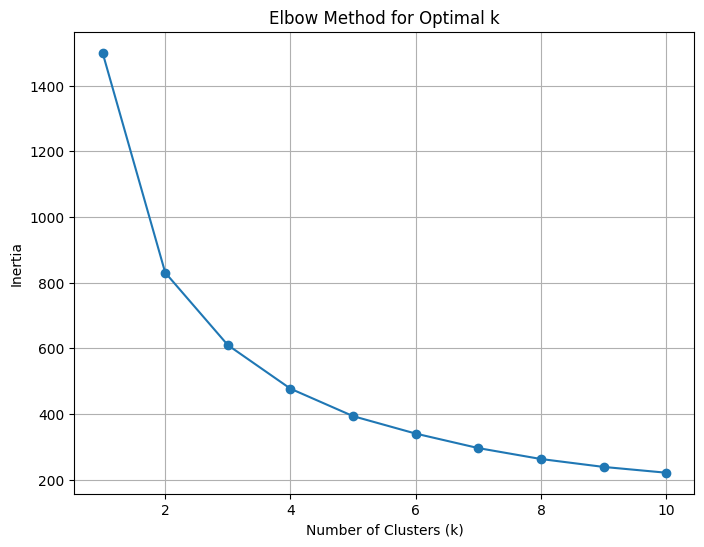


Successfully segmented customers into 4 clusters.
            Recency  Frequency  MonetaryValue  Cluster
CustomerID                                            
1                 7         14            775        1
2                 3         10            475        0
3                14          9            575        0
4                26         10            625        2
5                26         15            775        1

Cluster Summary (Averages):
         Recency  Frequency  MonetaryValue
Cluster                                   
0           7.17       9.28         568.28
1          24.74      13.72         867.24
2          51.79       9.26         576.12
3          64.49       5.38         311.94


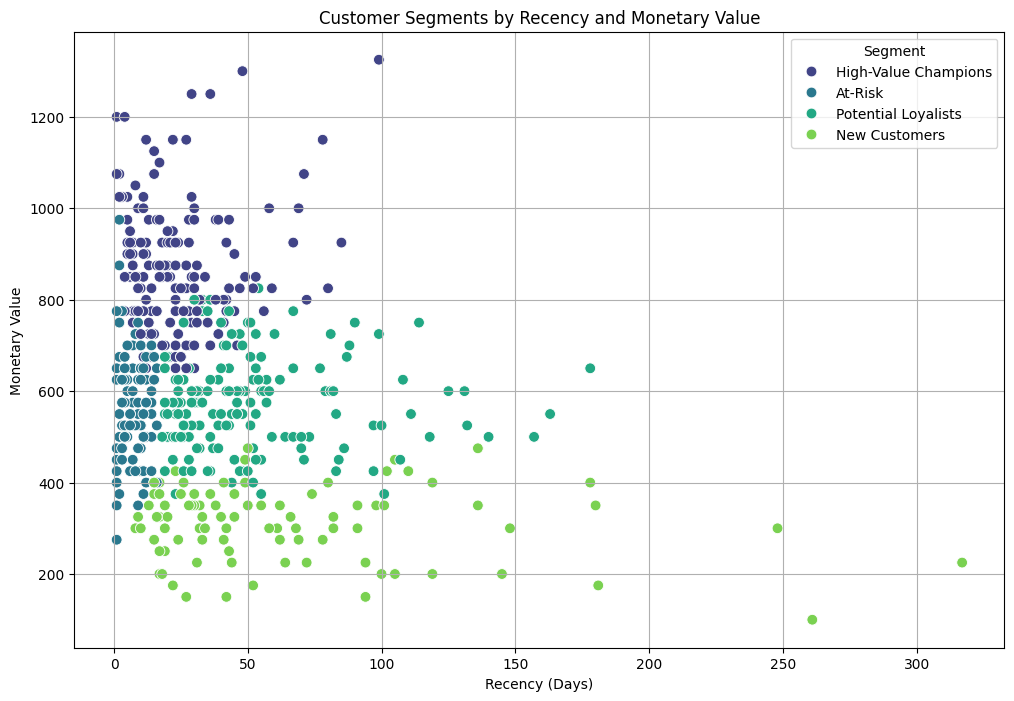

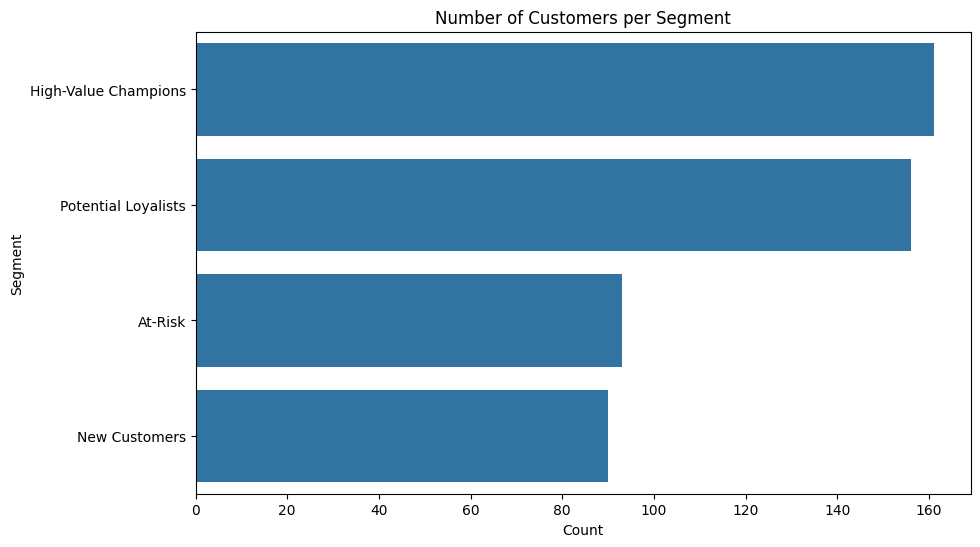


Final DataFrame with Segments:
            Recency  Frequency  MonetaryValue  Cluster               Segment
CustomerID                                                                  
1                 7         14            775        1  High-Value Champions
2                 3         10            475        0               At-Risk
3                14          9            575        0               At-Risk
4                26         10            625        2   Potential Loyalists
5                26         15            775        1  High-Value Champions


In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

# --- 1. Generate Synthetic Data ---
# In a real scenario, you would load your data from a CSV or database.
# Here, we create a sample dataset for demonstration purposes.
np.random.seed(42)
num_customers = 500
num_transactions = 5000

customer_ids = np.arange(1, num_customers + 1)
product_prices = {'Product A': 25, 'Product B': 50, 'Product C': 75, 'Product D': 100}

data = {
    'CustomerID': np.random.choice(customer_ids, num_transactions),
    'TransactionDate': [dt.date(2024, 1, 1) + dt.timedelta(days=np.random.randint(0, 365)) for _ in range(num_transactions)],
    'Amount': [np.random.choice(list(product_prices.values())) for _ in range(num_transactions)]
}
df = pd.DataFrame(data)

print("Sample of the generated data:")
print(df.head())
print("\nData Info:")
df.info()

# --- 2. Calculate RFM Metrics ---
# Recency, Frequency, Monetary value analysis.

# Set a snapshot date for analysis (e.g., the day after the last transaction)
snapshot_date = df['TransactionDate'].max() + dt.timedelta(days=1)
print(f"\nSnapshot date for RFM analysis: {snapshot_date}")

# Calculate RFM values
rfm_df = df.groupby('CustomerID').agg({
    'TransactionDate': lambda date: (snapshot_date - date.max()).days,
    'CustomerID': 'count',
    'Amount': 'sum'
})

# Rename columns for clarity
rfm_df.rename(columns={'TransactionDate': 'Recency',
                       'CustomerID': 'Frequency',
                       'Amount': 'MonetaryValue'}, inplace=True)

print("\nCalculated RFM values:")
print(rfm_df.head())

# --- 3. Preprocess Data for Clustering ---
# Address skewness and scale the data.

# Handle skew by applying log transformation (add 1 to avoid log(0))
rfm_log_df = np.log1p(rfm_df)

# Scale the data
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log_df)
rfm_scaled_df = pd.DataFrame(rfm_scaled, index=rfm_df.index, columns=rfm_df.columns)

print("\nScaled RFM data (first 5 rows):")
print(rfm_scaled_df.head())

# --- 4. K-Means Clustering ---
# Use the Elbow Method to find the optimal number of clusters.
inertia = {}
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled_df)
    inertia[k] = kmeans.inertia_

# Plot the Elbow Curve
plt.figure(figsize=(8, 6))
plt.plot(list(inertia.keys()), list(inertia.values()), marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

# Based on the elbow plot, let's choose k=3 or k=4. We'll use 4 for more granular segments.
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans.fit(rfm_scaled_df)

# Assign clusters back to the original RFM dataframe
rfm_df['Cluster'] = kmeans.labels_
print(f"\nSuccessfully segmented customers into {optimal_k} clusters.")
print(rfm_df.head())

# --- 5. Analyze and Visualize the Segments ---
# Calculate the average RFM values for each cluster.
cluster_summary = rfm_df.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'MonetaryValue': 'mean'
}).round(2)

print("\nCluster Summary (Averages):")
print(cluster_summary)

# Define personas based on the summary
# (This step is subjective and based on interpreting the cluster averages)
# Cluster 0: Low F, Low M, High R -> At-Risk/Lapsed Customers
# Cluster 1: High F, High M, Low R -> High-Value Champions
# Cluster 2: Mid F, Mid M, Mid R  -> Potential Loyalists
# Cluster 3: Low F, Low M, Low R -> New Customers

cluster_map = {
    0: 'At-Risk',
    1: 'High-Value Champions',
    2: 'Potential Loyalists',
    3: 'New Customers'
}
rfm_df['Segment'] = rfm_df['Cluster'].map(cluster_map)


# Visualize the segments
plt.figure(figsize=(12, 8))
sns.scatterplot(data=rfm_df, x='Recency', y='MonetaryValue', hue='Segment', palette='viridis', s=60)
plt.title('Customer Segments by Recency and Monetary Value')
plt.xlabel('Recency (Days)')
plt.ylabel('Monetary Value')
plt.legend(title='Segment')
plt.grid(True)
plt.show()

# Bar plot of segment sizes
plt.figure(figsize=(10, 6))
sns.countplot(y='Segment', data=rfm_df, order=rfm_df['Segment'].value_counts().index)
plt.title('Number of Customers per Segment')
plt.xlabel('Count')
plt.ylabel('Segment')
plt.show()

print("\nFinal DataFrame with Segments:")
print(rfm_df.head())